# Fig. 3: Matching RGC groups with bouton response types

## Imports

In [1]:
import os
import math
import random
import time
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from scipy.optimize import linear_sum_assignment
from scipy.interpolate import interp1d

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import KNeighborsClassifier

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Function
from torch.utils.data import TensorDataset, DataLoader, Sampler

In [2]:
save = 0

---

## Helper Functions

In [3]:
# ------------------------
# Global reproducibility
# ------------------------
def set_seed(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# ---------------------------------
# Helper: row-wise max-abs normalize
# ---------------------------------
def normalize_rows_max_abs(matrix):
    """
    Normalize each row so that the maximum absolute value in the row is 1.
    """
    row_max = np.max(np.abs(matrix), axis=1, keepdims=True)
    row_max[row_max == 0] = 1.0
    return matrix / row_max

# -----------------------------
# Domain linear probe (z-only)
# -----------------------------
def domain_linear_probe(Z, y_domain, n_splits=5, C=1.0, max_iter=2000, seed=42):
    Z = np.asarray(Z)
    y = np.asarray(y_domain)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    accs, aucs = [], []
    for tr, te in skf.split(Z, y):
        scaler = StandardScaler().fit(Z[tr])
        Ztr = scaler.transform(Z[tr])
        Zte = scaler.transform(Z[te])

        clf = LogisticRegression(
            solver="liblinear", C=C, max_iter=max_iter, random_state=seed
        ).fit(Ztr, y[tr])

        p = clf.predict_proba(Zte)[:, 1]
        accs.append(accuracy_score(y[te], (p > 0.5).astype(int)))
        try:
            aucs.append(roc_auc_score(y[te], p))
        except ValueError:
            pass

    return {
        "acc_mean": float(np.mean(accs)),
        "acc_std": float(np.std(accs)),
        "auc_mean": float(np.mean(aucs)) if len(aucs) > 0 else np.nan,
        "auc_std": float(np.std(aucs)) if len(aucs) > 0 else np.nan,
        "n_splits": n_splits,
    }


def domain_knn_probe(Z, y_domain, n_splits=5, k=10, seed=42):
    Z = np.asarray(Z)
    y = np.asarray(y_domain)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    accs = []

    for tr, te in skf.split(Z, y):
        clf = KNeighborsClassifier(n_neighbors=k)
        clf.fit(Z[tr], y[tr])
        preds = clf.predict(Z[te])
        accs.append(accuracy_score(y[te], preds))

    return np.mean(accs), np.std(accs)


# -----------------------------
# Domain linear probe (z-only)
# -----------------------------
def domain_linear_probe(Z, y_domain, n_splits=5, C=1.0, max_iter=2000, seed=42):
    Z = np.asarray(Z)
    y = np.asarray(y_domain)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

    accs, aucs = [], []
    for tr, te in skf.split(Z, y):
        scaler = StandardScaler().fit(Z[tr])
        Ztr = scaler.transform(Z[tr])
        Zte = scaler.transform(Z[te])

        clf = LogisticRegression(
            solver="liblinear", C=C, max_iter=max_iter, random_state=seed
        ).fit(Ztr, y[tr])

        p = clf.predict_proba(Zte)[:, 1]
        accs.append(accuracy_score(y[te], (p > 0.5).astype(int)))
        try:
            aucs.append(roc_auc_score(y[te], p))
        except ValueError:
            pass

    return {
        "acc_mean": float(np.mean(accs)),
        "acc_std": float(np.std(accs)),
        "auc_mean": float(np.mean(aucs)) if len(aucs) > 0 else np.nan,
        "auc_std": float(np.std(aucs)) if len(aucs) > 0 else np.nan,
        "n_splits": n_splits,
    }


def compute_corr(orig, recon):
    Xo = orig - orig.mean(axis=1, keepdims=True)
    Xr = recon  - recon.mean(axis=1, keepdims=True)
    num = np.sum(Xo * Xr, axis=1)
    den = np.sqrt(np.sum(Xo**2, axis=1) * np.sum(Xr**2, axis=1))
    corr = num / den
    return corr



def find_block(idx, blocks):
    for b, (start, end) in enumerate(blocks):
        if start <= idx <= end:
            return b
    return None 

def compute_corr_summary(matrix):
    row_blocks = [
        (0, 8),   
        (8, 14),  
        (14, 19), 
        (19, 27),
        (27, 29),
        (29, 32),
    ]
    col_blocks = [
        (0, 4),    
        (5, 9),    
        (10, 17),  
        (18, 23),  
        (24, 29),  
        (30, 33), 
        (34, 40),
        (41, 45), 
        (46, 49), 
    ]
    
    n_row_blocks = len(row_blocks)
    n_col_blocks = len(col_blocks)

    n_rows, n_cols = matrix.shape
    assert n_rows == 32 and n_cols == 50

    # ------------------------
    # Argmax-based block counts
    # ------------------------
    star_cols = np.argmax(matrix, axis=1)
    block_counts = np.zeros((n_row_blocks, n_col_blocks), dtype=int)

    for i in range(n_rows):
        j = star_cols[i]
        r_block = find_block(i, row_blocks)
        c_block = find_block(j, col_blocks)
        if r_block is not None and c_block is not None:
            block_counts[r_block, c_block] += 1

    row_sums = block_counts.sum(axis=1, keepdims=True)
    block_counts_norm = np.divide(
        block_counts, row_sums,
        out=np.zeros_like(block_counts, dtype=float),
        where=row_sums != 0
    )

    # ------------------------
    # Mean value per block
    # ------------------------
    block_sum = np.zeros((n_row_blocks, n_col_blocks))
    block_n = np.zeros((n_row_blocks, n_col_blocks), dtype=int)

    for rb, (r0, r1) in enumerate(row_blocks):
        for cb, (c0, c1) in enumerate(col_blocks):
            sub = matrix[r0:r1, c0:c1]
            block_sum[rb, cb] = sub.sum()
            block_n[rb, cb] = sub.size

    block_mean = np.divide(
        block_sum, block_n,
        out=np.zeros_like(block_sum),
        where=block_n != 0
    )

    return block_counts_norm, block_mean

## Data Loading

In [4]:
# --------------------
# Load SC dataset
# --------------------
print("Loading SC data...")
df_sc_labels = pd.read_hdf("/MY_PATH/sc_retinal_axons_clusters_clean.h5", key="df")
df_sc_all = pd.read_pickle("/MY_PATH/20240207_df_clusterd_identified.pkl")
df_sc = df_sc_labels.combine_first(df_sc_all).loc[df_sc_labels.index]

# add bar infos
with open('/MY_PATH/df_os_ds.pkl', 'rb') as f:
    df_os_ds = pickle.load(f)
new_cols = df_os_ds.columns.difference(df_sc.columns)
df_sc = df_sc.join(df_os_ds.loc[df_sc.index, new_cols])

labels_sc = df_sc["clusterID"].values.astype(int)
resp_chirp_sc = df_sc["resp_chirp"].values  # list/array of traces
X_sc = np.stack(resp_chirp_sc)              # (N_sc, T_sc)
X_sc_bar = np.stack(df_sc["time_comps"].values) 

# --------------------
# Load RGC dataset
# --------------------
print("Loading RGC data...")
df_all_rgc = pd.read_pickle("/MY_PATH/all_RGC_table_20250901.pkl")

df_rgc = df_all_rgc[
    (df_all_rgc["chirp_qidx"] > 0.35) | (df_all_rgc["bar_qidx"] > 0.6)
]
df_rgc = df_rgc[df_rgc["animgender"].isin(["male", "female"])]
df_rgc = df_rgc[df_rgc["cond1"].isin(["C1", "C2", "c1", "c3", "c4", "control"])]

df_rgc = df_rgc.reset_index(drop=True)

# restrict group_id < 33 as before
df_rgc = df_rgc[df_rgc["group_id"] < 33]
df_rgc = df_rgc.reset_index(drop=True)

# RGC traces
X_rgc = np.stack(df_rgc["chirp_8Hz_average_norm"])  
X_rgc_bar = np.stack(df_rgc["preproc_bar"].values) 

# RGC types
y_rgc = df_rgc["group_id"].values.copy().astype(int)
y_rgc -= 1  

# SC types
y_sc = labels_sc.copy()

print("RGC shape:", X_rgc.shape, "types:", np.unique(y_rgc))
print("SC  shape:", X_sc.shape,  "types:", np.unique(y_sc))

Loading SC data...
Loading RGC data...
RGC shape: (26054, 259) types: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31]
SC  shape: (45512, 260) types: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49]


---

## Data Resampling & Normalization (Chirp)

In [5]:
# ----------------------------
# Resample both to length 260
# ----------------------------
print("Resampling traces to 260 samples...")

T_target = 260
t_common = np.linspace(0, 32, T_target)

# RGC time axis
t_rgc = np.linspace(0, 32, X_rgc.shape[1])
interp_rgc = interp1d(t_rgc, X_rgc, kind="linear", axis=1)
X_rgc_resampled = interp_rgc(t_common)

# SC time axis
t_sc = np.linspace(0, 32, X_sc.shape[1])
interp_sc = interp1d(t_sc, X_sc, kind="linear", axis=1)
X_sc_resampled = interp_sc(t_common)

# Normalize
X_rgc_norm_abs = normalize_rows_max_abs(X_rgc_resampled)
X_sc_norm_abs  = normalize_rows_max_abs(X_sc_resampled)

print("RGC resampled:", X_rgc_norm_abs.shape)
print("SC  resampled:", X_sc_norm_abs.shape)

Resampling traces to 260 samples...
RGC resampled: (26054, 260)
SC  resampled: (45512, 260)


## Add Moving bar responses to Datasets

In [6]:
# --------------------------------------
# Build combined dataset with MB
# --------------------------------------

X_rgc_norm_abs = np.hstack((X_rgc_norm_abs, X_rgc_bar))
X_sc_norm_abs = np.hstack((X_sc_norm_abs, X_sc_bar))

print("RGC combined chirp + bar:", X_rgc_norm_abs.shape)
print("SC  combined chirp + bar:", X_sc_norm_abs.shape)

RGC combined chirp + bar: (26054, 292)
SC  combined chirp + bar: (45512, 292)


## Data Preparation

In [7]:
# --------------------------------------
# Build combined dataset for VAE + DANN
# --------------------------------------
print("Building combined dataset...")

X_combined = np.vstack([X_rgc_norm_abs, X_sc_norm_abs]).astype(np.float32)

# Domain labels: 0=RGC, 1=SC
domain_labels = np.array(
    [0] * len(X_rgc_norm_abs) +
    [1] * len(X_sc_norm_abs),
    dtype=np.int64
)

# Type labels: separate channels for RGC and SC
y_rgc_full = np.full(len(X_combined), -1, dtype=np.int64)
y_sc_full  = np.full(len(X_combined), -1, dtype=np.int64)

y_rgc_full[:len(X_rgc_norm_abs)] = y_rgc
y_sc_full[len(X_rgc_norm_abs):]  = y_sc

is_rgc = (domain_labels == 0)
is_sc  = (domain_labels == 1)

X_tensor      = torch.tensor(X_combined,   dtype=torch.float32)
dom_tensor    = torch.tensor(domain_labels, dtype=torch.long)
y_rgc_tensor  = torch.tensor(y_rgc_full,   dtype=torch.long)
y_sc_tensor   = torch.tensor(y_sc_full,    dtype=torch.long)
is_rgc_tensor = torch.tensor(is_rgc,       dtype=torch.bool)
is_sc_tensor  = torch.tensor(is_sc,        dtype=torch.bool)

dataset = TensorDataset(
    X_tensor,
    dom_tensor,
    y_rgc_tensor,
    y_sc_tensor,
    is_rgc_tensor,
    is_sc_tensor,
)

Building combined dataset...


---

## Define Model

In [8]:
# --------------------------------------------
# Domain-balanced batch sampler (optional)
# --------------------------------------------
class DomainBalancedBatchSampler(Sampler):
    """
    Ensures each batch has half RGC, half SC.
    """
    def __init__(self, domain_labels, batch_size=512):
        self.domain_labels = np.asarray(domain_labels)
        self.dom0 = np.where(self.domain_labels == 0)[0].tolist()
        self.dom1 = np.where(self.domain_labels == 1)[0].tolist()
        self.bs_half = batch_size // 2

    def __iter__(self):
        random.shuffle(self.dom0)
        random.shuffle(self.dom1)
        for i in range(0, min(len(self.dom0), len(self.dom1)), self.bs_half):
            b0 = self.dom0[i:i + self.bs_half]
            b1 = self.dom1[i:i + self.bs_half]
            if len(b0) == self.bs_half and len(b1) == self.bs_half:
                yield b0 + b1

    def __len__(self):
        return min(len(self.dom0), len(self.dom1)) // self.bs_half

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(42)

balanced_dataset = 1
batch_size = 512

if balanced_dataset == 1:
    sampler = DomainBalancedBatchSampler(domain_labels, batch_size=batch_size)
    loader = DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=4,
        worker_init_fn=seed_worker,
        generator=g,
    )
else:
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        worker_init_fn=seed_worker,
        generator=g,
    )

# ---------------------------
# Gradient Reversal Layer
# ---------------------------
class ReverseLayerF(Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

    
class DomainDiscriminator(nn.Module):
    def __init__(self, latent_dim: int, hidden_dim: int = 128, p_drop: float = 0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p_drop),
            nn.Linear(hidden_dim, 2),  
        )

    def forward(self, z):
        return self.net(z)


# ---------------------------
# VAE + DANN architecture
# ---------------------------
class VAE_DANN(nn.Module):
    def __init__(
        self,
        input_dim=260,
        latent_dim=32,
        hidden_dim=128,
        n_types_rgc=32,
        n_types_sc=50,
        p_drop=0.2
    ):
        super().__init__()

        # Encoder: x -> shared hidden
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p_drop),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        # Latent parameters
        self.enc_mu     = nn.Linear(hidden_dim, latent_dim)
        self.enc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder: z -> x_hat
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

        # Type heads (domain-specific)
        self.type_head_rgc = nn.Sequential(
            nn.Linear(latent_dim, latent_dim),
            nn.ReLU(),
            nn.Linear(latent_dim, n_types_rgc)
        )

        self.type_head_sc = nn.Sequential(
            nn.Linear(latent_dim, latent_dim),
            nn.ReLU(),
            nn.Linear(latent_dim, n_types_sc)
        )

        self.domain_head = DomainDiscriminator(latent_dim, hidden_dim=hidden_dim, p_drop=p_drop)

    def encode(self, x):
        h = self.encoder(x)
        mu = self.enc_mu(h)
        logvar = self.enc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x, alpha=1.0):
        # VAE path
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)

        # Domain head with GRL
        z_rev = ReverseLayerF.apply(z, alpha)
        dom_logits = self.domain_head(z_rev)

        # Type heads
        logits_rgc = self.type_head_rgc(z)
        logits_sc  = self.type_head_sc(z)

        return {
            "x_hat": x_hat,
            "mu": mu,
            "logvar": logvar,
            "z": z,
            "dom_logits": dom_logits,
            "logits_rgc": logits_rgc,
            "logits_sc": logits_sc,
        }

## Model Training Function

In [9]:
# -------------------------
# Training function
# -------------------------
def train_vae_dann(
    model,
    loader,
    epochs=100,
    lr=1e-3,
    weight_decay=1e-4,
    lambda_recon=1.0,
    lambda_kl=1e-3,
    lambda_type=1.0,
    lambda_domain=1.0,
    grl_max_alpha=1.0,
    grl_k=10.0,
    device="cpu",
):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    ce_loss = nn.CrossEntropyLoss(reduction="mean")
    mse_loss = nn.MSELoss(reduction="mean")

    def kl_div(mu, logvar):
        return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    hist = {
        "recon": [],
        "kl": [],
        "type_rgc": [],
        "type_sc": [],
        "dom": [],
        "acc_rgc": [],
        "acc_sc": [],
        "acc_dom": [],
    }

    def grl_alpha(epoch_idx):
        p = epoch_idx / float(epochs)
        return grl_max_alpha * (2.0 / (1.0 + math.exp(-grl_k * p)) - 1.0)

    for epoch in range(epochs):
        model.train()
        total_recon = total_kl = total_type_rgc = total_type_sc = total_dom = 0.0
        correct_rgc = correct_sc = correct_dom = 0
        count_rgc = count_sc = count_dom = 0
        t0 = time.time()

        alpha = grl_alpha(epoch)

        for batch in loader:
            x, d, y_rgc, y_sc, is_rgc, is_sc = batch
            x       = x.to(device)
            d       = d.to(device)
            y_rgc   = y_rgc.to(device)
            y_sc    = y_sc.to(device)
            is_rgc  = is_rgc.to(device)
            is_sc   = is_sc.to(device)

            out = model(x, alpha=alpha)

            x_hat      = out["x_hat"]
            mu         = out["mu"]
            logvar     = out["logvar"]
            dom_logits = out["dom_logits"]
            logits_rgc = out["logits_rgc"]
            logits_sc  = out["logits_sc"]

            # Reconstruction + KL
            L_recon = mse_loss(x_hat, x)
            L_kl    = kl_div(mu, logvar)

            # Type losses
            L_type_rgc = torch.tensor(0.0, device=device)
            L_type_sc  = torch.tensor(0.0, device=device)

            if is_rgc.any():
                L_type_rgc = ce_loss(logits_rgc[is_rgc], y_rgc[is_rgc])
                preds_rgc  = logits_rgc[is_rgc].argmax(dim=1)
                correct_rgc += (preds_rgc == y_rgc[is_rgc]).sum().item()
                count_rgc   += is_rgc.sum().item()

            if is_sc.any():
                L_type_sc = ce_loss(logits_sc[is_sc], y_sc[is_sc])
                preds_sc  = logits_sc[is_sc].argmax(dim=1)
                correct_sc += (preds_sc == y_sc[is_sc]).sum().item()
                count_sc   += is_sc.sum().item()

            L_type = L_type_rgc + L_type_sc

            # Domain loss (all samples)
            L_dom = ce_loss(dom_logits, d)
            preds_dom = dom_logits.argmax(dim=1)
            correct_dom += (preds_dom == d).sum().item()
            count_dom   += d.numel()

            # Total loss
            loss = (
                lambda_recon * L_recon +
                lambda_kl    * L_kl +
                lambda_type  * L_type +
                lambda_domain * L_dom
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_recon    += L_recon.item()
            total_kl       += L_kl.item()
            total_type_rgc += L_type_rgc.item()
            total_type_sc  += L_type_sc.item()
            total_dom      += L_dom.item()

        n_batches = len(loader)
        avg_recon = total_recon / n_batches
        avg_kl    = total_kl    / n_batches
        avg_trgc  = total_type_rgc / n_batches
        avg_tsc   = total_type_sc  / n_batches
        avg_dom   = total_dom / n_batches

        acc_rgc = correct_rgc / max(1, count_rgc)
        acc_sc  = correct_sc  / max(1, count_sc)
        acc_dom = correct_dom / max(1, count_dom)

        hist["recon"].append(avg_recon)
        hist["kl"].append(avg_kl)
        hist["type_rgc"].append(avg_trgc)
        hist["type_sc"].append(avg_tsc)
        hist["dom"].append(avg_dom)
        hist["acc_rgc"].append(acc_rgc)
        hist["acc_sc"].append(acc_sc)
        hist["acc_dom"].append(acc_dom)

        print(
            f"Epoch {epoch+1:03d} | "
            f"Recon {avg_recon:.4f}  KL {avg_kl:.4f}  "
            f"Type RGC {avg_trgc:.4f}  Type SC {avg_tsc:.4f}  "
            f"Dom {avg_dom:.4f} | "
            f"Acc RGC {acc_rgc:.3f}  Acc SC {acc_sc:.3f}  "
            f"Acc Dom {acc_dom:.3f}  (alpha={alpha:.2f})  "
            f"time {time.time()-t0:.2f}s"
        )

    # Quick plots
    fig, ax = plt.subplots(2, 3, figsize=(14, 8))
    ax = ax.ravel()

    ax[0].plot(hist["recon"]); ax[0].set_title("Recon loss"); ax[0].grid(True)
    ax[1].plot(hist["kl"]); ax[1].set_title("KL loss"); ax[1].grid(True)
    ax[2].plot(hist["type_rgc"], label="RGC"); ax[2].plot(hist["type_sc"], label="SC")
    ax[2].set_title("Type loss"); ax[2].legend(); ax[2].grid(True)
    ax[3].plot(hist["dom"]); ax[3].set_title("Domain loss"); ax[3].grid(True)
    ax[4].plot(hist["acc_rgc"], label="RGC"); ax[4].plot(hist["acc_sc"], label="SC")
    ax[4].set_title("Type accuracy"); ax[4].legend(); ax[4].grid(True)
    ax[5].plot(hist["acc_dom"]); ax[5].set_title("Domain acc"); ax[5].grid(True)

    plt.tight_layout()
    plt.show()

    return hist

In [10]:
# ======================
# RUN TRAINING
# ======================
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

n_types_rgc = len(np.unique(y_rgc))
n_types_sc  = len(np.unique(y_sc))

Using device: cuda


---

## Initilise Model

In [11]:
model_vae_dann = VAE_DANN(
    input_dim=292,
    latent_dim=8,
    hidden_dim=128,
    n_types_rgc=n_types_rgc,
    n_types_sc=n_types_sc,
    p_drop=0.2,
)

## Train Model

Epoch 009 | Recon 0.0488  KL 19.4352  Type RGC 1.2507  Type SC 1.2786  Dom 0.6883 | Acc RGC 0.559  Acc SC 0.584  Acc Dom 0.539  (alpha=0.38)  time 1.71s


Epoch 010 | Recon 0.0523  KL 19.6201  Type RGC 1.2343  Type SC 1.2402  Dom 0.6925 | Acc RGC 0.561  Acc SC 0.595  Acc Dom 0.529  (alpha=0.42)  time 1.48s


Epoch 011 | Recon 0.0533  KL 18.3300  Type RGC 1.2011  Type SC 1.2009  Dom 0.6882 | Acc RGC 0.569  Acc SC 0.607  Acc Dom 0.530  (alpha=0.46)  time 1.85s


Epoch 012 | Recon 0.0548  KL 21.1432  Type RGC 1.2147  Type SC 1.2250  Dom 0.6949 | Acc RGC 0.566  Acc SC 0.594  Acc Dom 0.526  (alpha=0.50)  time 1.71s


Epoch 013 | Recon 0.0514  KL 18.1959  Type RGC 1.1602  Type SC 1.1271  Dom 0.6940 | Acc RGC 0.586  Acc SC 0.626  Acc Dom 0.530  (alpha=0.54)  time 1.73s


...

Epoch 046 | Recon 0.0505  KL 12.5504  Type RGC 0.9456  Type SC 0.7964  Dom 0.6938 | Acc RGC 0.640  Acc SC 0.738  Acc Dom 0.500  (alpha=0.98)  time 2.18s


Epoch 047 | Recon 0.0492  KL 13.4748  Type RGC 0.9392  Type SC 0.7871  Dom 0.6924 | Acc RGC 0.645  Acc SC 0.737  Acc Dom 0.512  (alpha=0.98)  time 2.12s


Epoch 048 | Recon 0.0482  KL 14.3948  Type RGC 0.9378  Type SC 0.7809  Dom 0.6939 | Acc RGC 0.646  Acc SC 0.738  Acc Dom 0.504  (alpha=0.98)  time 2.30s


Epoch 049 | Recon 0.0486  KL 12.7371  Type RGC 0.9319  Type SC 0.7646  Dom 0.6934 | Acc RGC 0.648  Acc SC 0.741  Acc Dom 0.505  (alpha=0.98)  time 1.52s


Epoch 050 | Recon 0.0496  KL 11.6234  Type RGC 0.9055  Type SC 0.7194  Dom 0.6923 | Acc RGC 0.654  Acc SC 0.758  Acc Dom 0.516  (alpha=0.99)  time 1.74s


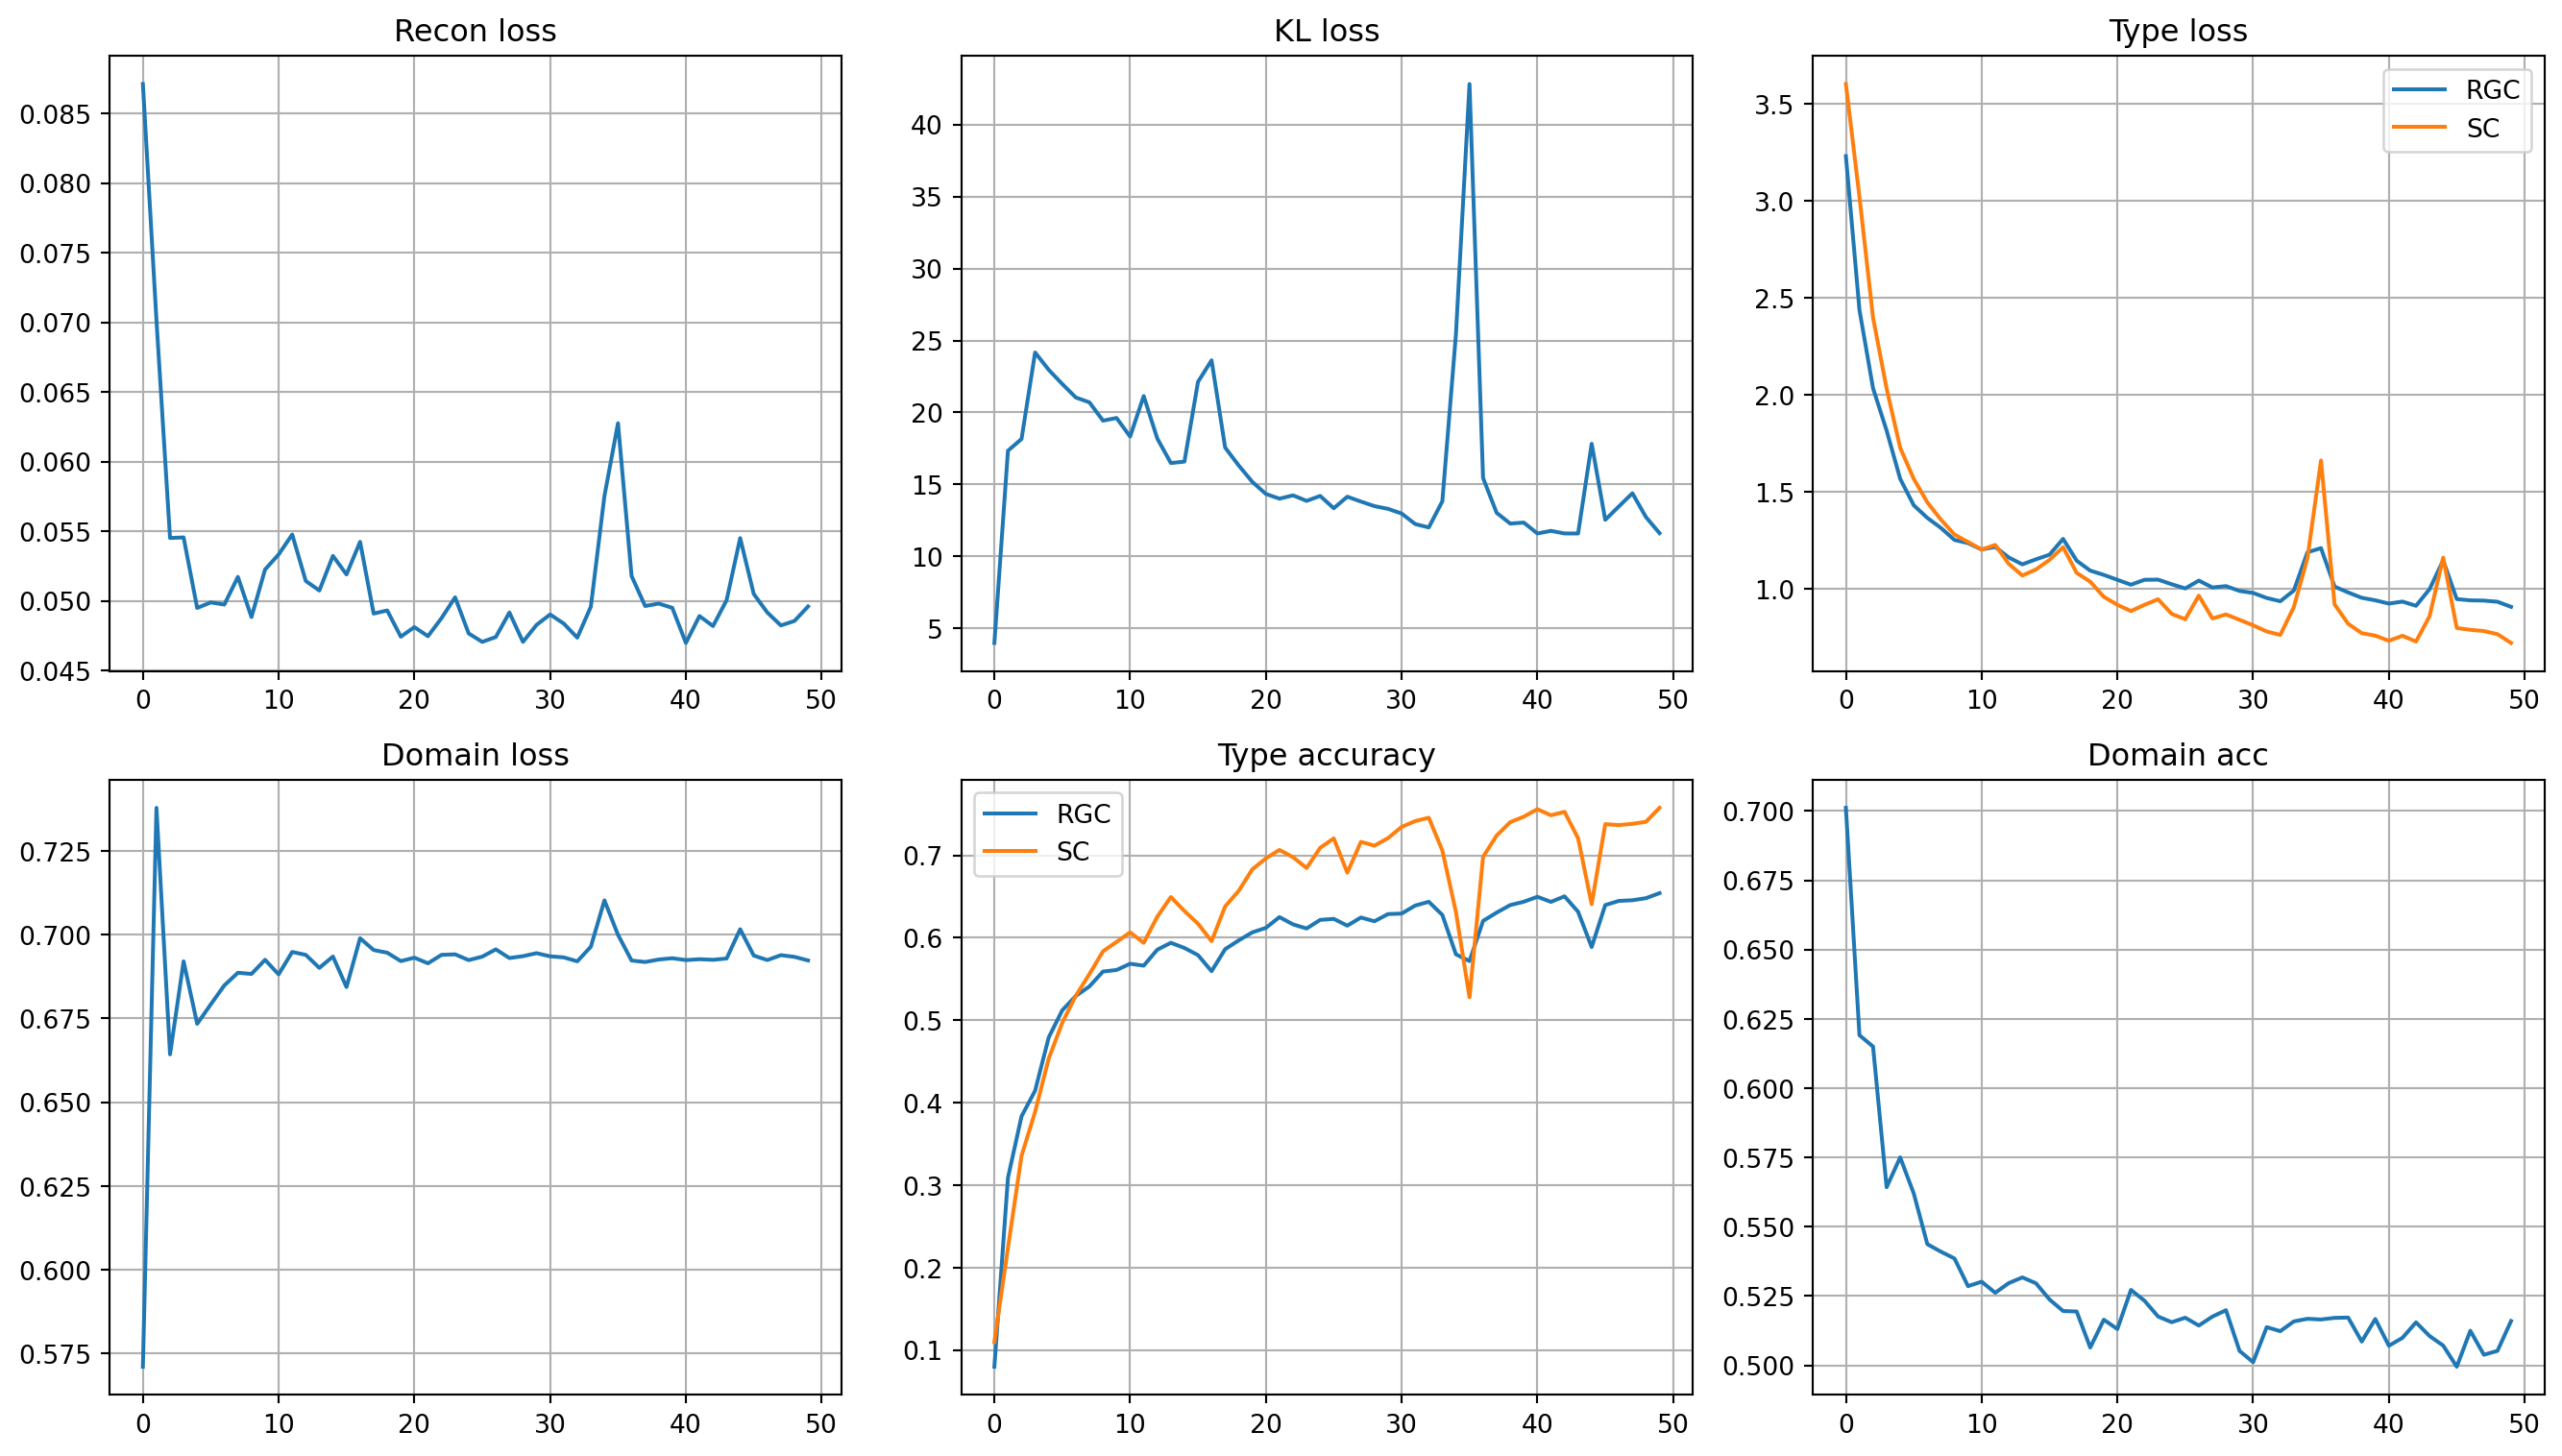

In [ ]:
hist = train_vae_dann(
    model=model_vae_dann,
    loader=loader,
    epochs=1000,
    lr=1e-3,
    weight_decay=1e-4,
    lambda_recon=1.0,
    lambda_kl=1e-2,
    lambda_type=1.0,
    lambda_domain=20.0,
    grl_max_alpha=1.0,
    grl_k=5.0,
    device=device,
)

---

## Save model and its output

In [ ]:
#save_path = "/gpfs01/euler/User/dgonschorek/projects/_3_Postdoc/superior_colliculus/data/vae_dann_checkpoint.pt"
save_path = "/MY_PATH/vae_checkpoint.pt"
torch.save({"model_state_dict": model_vae_dann.state_dict(),}, save_path)

## If already ran and saved: load model & outputs

In [12]:
#checkpoint = torch.load("/gpfs01/euler/User/dgonschorek/projects/_3_Postdoc/superior_colliculus/data/vae_dann_checkpoint.pt", map_location=device, weights_only=True )
checkpoint = torch.load("/MY_PATH/vae_checkpoint.pt", map_location=device, weights_only=True )

model_vae_dann.load_state_dict(checkpoint["model_state_dict"])
model_vae_dann.to(device)
model_vae_dann.eval()

VAE_DANN(
  (encoder): Sequential(
    (0): Linear(in_features=292, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
  )
  (enc_mu): Linear(in_features=128, out_features=8, bias=True)
  (enc_logvar): Linear(in_features=128, out_features=8, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=292, bias=True)
  )
  (type_head_rgc): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=32, bias=True)
  )
  (type_head_sc): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=50, bias=True)
  )
  (domain_head): DomainDiscriminator(
    (net): Sequential(
      (0): Linear(in_features=8, out_features=128, bias=True)
      (1): 

---

## Model Evaluation

In [13]:
model_vae_dann.eval()
with torch.no_grad():
    x_all = X_tensor.to(device)
    out = model_vae_dann(x_all, alpha=0.0)  
    x_hat_all = out["x_hat"].cpu().numpy()
    mu, logvar = model_vae_dann.encode(x_all)
    z_all = mu.cpu().numpy()  

### Compute Domain Accuracy (Linear classifier)

In [14]:
probe = domain_linear_probe(z_all, domain_labels, n_splits=5)
probe_raw = domain_linear_probe(X_combined, domain_labels, n_splits=5)
probe_recon = domain_linear_probe(x_hat_all, domain_labels, n_splits=5)

print(f"[Domain probe on z]  Acc = {probe['acc_mean']:.3f}±{probe['acc_std']:.3f} | " f"AUC = {probe['auc_mean']:.3f}±{probe['auc_std']:.3f}")
print(f"[Domain probe on Recon]  Acc = {probe_recon['acc_mean']:.3f}±{probe_recon['acc_std']:.3f} | " f"AUC = {probe_recon['auc_mean']:.3f}±{probe_recon['auc_std']:.3f}")
print(f"[Domain probe on Raw]  Acc = {probe_raw['acc_mean']:.3f}±{probe_raw['acc_std']:.3f} | " f"AUC = {probe_raw['auc_mean']:.3f}±{probe_raw['auc_std']:.3f}")

[Domain probe on z]  Acc = 0.628±0.001 | AUC = 0.587±0.007
[Domain probe on Recon]  Acc = 0.685±0.004 | AUC = 0.716±0.004
[Domain probe on Raw]  Acc = 0.927±0.002 | AUC = 0.974±0.001


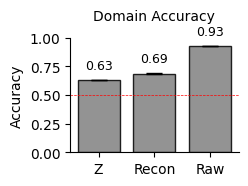

In [15]:
means = [probe['acc_mean'], probe_recon['acc_mean'], probe_raw['acc_mean']]
stds  = [probe['acc_std'],  probe_recon['acc_std'],  probe_raw['acc_std']]
labels = ['Z', 'Recon', 'Raw']
x = np.arange(len(means))

fig, ax = plt.subplots(figsize=(2.5,2))
bars = ax.bar(x, means, yerr=stds, width=0.75,capsize=6, alpha=0.85, edgecolor='k', color='gray')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Accuracy')
ax.set_title('Domain Accuracy',fontsize=10,y=1.08)

for bar, m in zip(bars, means):
    h = bar.get_height()
    ax.annotate(f'{m:.2f}', 
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 6),  # offset text above the bar
                textcoords='offset points',
                ha='center', va='bottom', fontsize=9)
ax.set_ylim(0,1)
ax.axhline(0.5,lw=0.5,ls='--',color='r')
sns.despine()
plt.tight_layout()
plt.show()

### Compute kNN accuracy

In [17]:
acc_z, std_z = domain_knn_probe(z_all, domain_labels)
acc_raw, std_raw = domain_knn_probe(X_combined, domain_labels)
acc_rec, std_rec = domain_knn_probe(x_hat_all, domain_labels)

print(f"[kNN Domain Probe - z]   {acc_z:.3f} ± {std_z:.3f}")
print(f"[kNN Domain Probe - raw] {acc_raw:.3f} ± {std_raw:.3f}")
print(f"[kNN Domain Probe - rec] {acc_rec:.3f} ± {std_rec:.3f}")

[kNN Domain Probe - z]   0.830 ± 0.002
[kNN Domain Probe - raw] 0.987 ± 0.001
[kNN Domain Probe - rec] 0.780 ± 0.003


### MSE on reconstructions

In [18]:
X_np    = X_tensor.cpu().numpy()
xhat_np = x_hat_all 
mse_per_cell = ((xhat_np - X_np) ** 2).mean(axis=1)
mse_norm = mse_per_cell / 4.0

# split RGC / SC
n_rgc = len(X_rgc_norm_abs)
mse_rgc = mse_norm[:n_rgc]
mse_sc  = mse_norm[n_rgc:]

y_rgc_only = y_rgc_full[:n_rgc]
y_sc_only  = y_sc_full[n_rgc:]

uniq_rgc = np.unique(y_rgc_only[y_rgc_only >= 0])
uniq_sc  = np.unique(y_sc_only[y_sc_only >= 0])

# ---- RGC ----
print("\n=== RGC normalized MSE per type (0-1) ===")
for t in uniq_rgc:
    vals = mse_rgc[y_rgc_only == t]
    print(f"RGC type {t:2d}: MSE_norm = {vals.mean():.4f} (n={vals.size})")

print("\n=== RGC normalized MSE overall (0-1) ===")
print(f"RGC overall MSE_norm = {mse_rgc.mean():.4f}")

# ---- SC ----
print("\n=== SC normalized MSE per type (0-1) ===")
for t in uniq_sc:
    vals = mse_sc[y_sc_only == t]
    print(f"SC  type {t:2d}: MSE_norm = {vals.mean():.4f} (n={vals.size})")

print("\n=== SC normalized MSE overall (0-1) ===")
print(f"SC overall MSE_norm = {mse_sc.mean():.4f}")


=== RGC normalized MSE per type (0-1) ===
RGC type  0: MSE_norm = 0.0150 (n=724)
RGC type  1: MSE_norm = 0.0171 (n=898)
RGC type  2: MSE_norm = 0.0114 (n=362)
RGC type  3: MSE_norm = 0.0153 (n=1010)
RGC type  4: MSE_norm = 0.0125 (n=338)
RGC type  5: MSE_norm = 0.0130 (n=667)
RGC type  6: MSE_norm = 0.0113 (n=860)
RGC type  7: MSE_norm = 0.0092 (n=188)
RGC type  8: MSE_norm = 0.0088 (n=231)
RGC type  9: MSE_norm = 0.0143 (n=786)
RGC type 10: MSE_norm = 0.0133 (n=1024)
RGC type 11: MSE_norm = 0.0153 (n=1925)
RGC type 12: MSE_norm = 0.0311 (n=913)
RGC type 13: MSE_norm = 0.0253 (n=966)
RGC type 14: MSE_norm = 0.0093 (n=115)
RGC type 15: MSE_norm = 0.0212 (n=245)
RGC type 16: MSE_norm = 0.0166 (n=1695)
RGC type 17: MSE_norm = 0.0085 (n=527)
RGC type 18: MSE_norm = 0.0096 (n=55)
RGC type 19: MSE_norm = 0.0136 (n=307)
RGC type 20: MSE_norm = 0.0091 (n=560)
RGC type 21: MSE_norm = 0.0101 (n=1628)
RGC type 22: MSE_norm = 0.0068 (n=1310)
RGC type 23: MSE_norm = 0.0067 (n=239)
RGC type 24: MSE

In [19]:
# ---- split back into RGC / SC ----
n_rgc = len(X_rgc_norm_abs)
n_sc  = len(X_sc_norm_abs)

X_orig_rgc = X_combined[:n_rgc]
X_orig_sc  = X_combined[n_rgc:]

X_rec_rgc = x_hat_all[:n_rgc]
X_rec_sc  = x_hat_all[n_rgc:]

# split RGC into chirp & bar
X_orig_rgc_chirp = X_orig_rgc[:,:260]
X_orig_rgc_bar = X_orig_rgc[:,260:]
X_rec_rgc_chirp = X_rec_rgc[:,:260]
X_rec_rgc_bar = X_rec_rgc[:,260:]

# split SC into chirp & bar
X_orig_sc_chirp = X_orig_sc[:,:260]
X_orig_sc_bar = X_orig_sc[:,260:]
X_rec_sc_chirp = X_rec_sc[:,:260]
X_rec_sc_bar = X_rec_sc[:,260:]

### MSE of RGCs

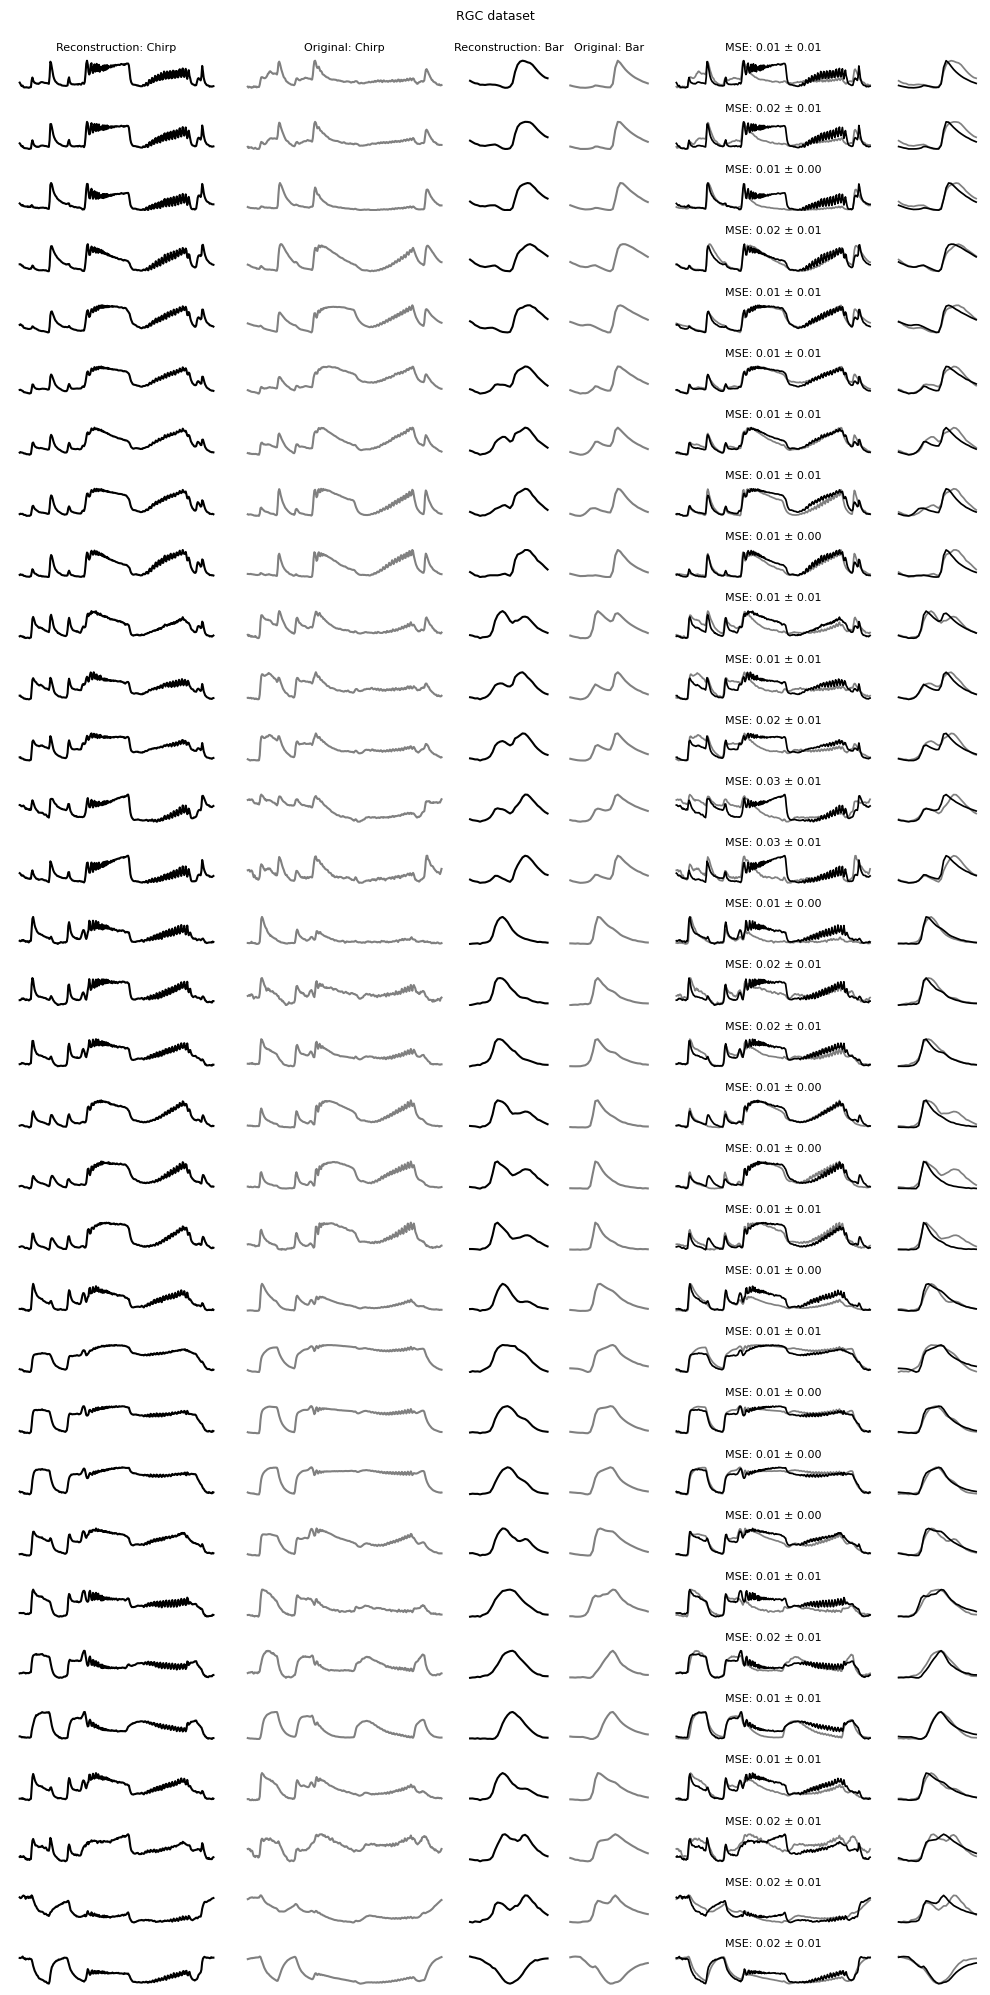

In [20]:
fig, ax = plt.subplots(32, 6, figsize=(10, 20),gridspec_kw={'width_ratios': [2.5, 2.5, 1., 1., 2.5, 1.]})

for i in range(len(np.unique(y_rgc))):
    idx = np.where(y_rgc == i)[0]

    mean_rgc_recon_chirp = X_rec_rgc_chirp[idx, :].mean(axis=0)
    mean_rgc_orig_chirp = X_orig_rgc_chirp[idx, :].mean(axis=0)

    mean_rgc_recon_bar = X_rec_rgc_bar[idx, :].mean(axis=0)
    mean_rgc_orig_bar = X_orig_rgc_bar[idx, :].mean(axis=0)
    
    # main axis
    ax[i,1].plot(mean_rgc_orig_chirp, color='gray', label='Original')
    ax[i,0].plot(mean_rgc_recon_chirp, color='k', label='Recon')
    ax[i,3].plot(mean_rgc_orig_bar, color='gray', label='Original')
    ax[i,2].plot(mean_rgc_recon_bar, color='k', label='Recon')
    
    # twin axis sharing x
    lw=1.25
    ax[i,4].plot(mean_rgc_orig_chirp, color='gray', label='Recon',lw=lw)
    ax2 = ax[i,4].twinx()
    ax2.plot(mean_rgc_recon_chirp, color='k', label='Original',lw=lw)

    ax[i,5].plot(mean_rgc_recon_bar, color='gray', label='Recon',lw=lw)
    ax3 = ax[i,5].twinx()
    ax3.plot(mean_rgc_orig_bar, color='k', label='Original',lw=lw)

    ax[i,0].axis('off')     
    ax[i,1].axis('off')      
    ax[i,2].axis('off') 
    ax[i,3].axis('off')     
    ax[i,4].axis('off')     
    ax[i,5].axis('off')     
    ax2.axis('off')
    ax3.axis('off')
    ax[0,0].set_title('Reconstruction: Chirp',fontsize=8)
    ax[0,1].set_title('Original: Chirp',fontsize=8)
    ax[0,2].set_title('Reconstruction: Bar',fontsize=8)
    ax[0,3].set_title('Original: Bar',fontsize=8)
    ax[i,4].set_title(f"MSE: {mse_rgc[y_rgc_only == i].mean():.2f} ± {mse_rgc[y_rgc_only == i].std():.2f}",fontsize=8)
fig.suptitle('RGC dataset', y=0.995, fontsize=9)
fig.tight_layout()
plt.show()

### MSE of SC

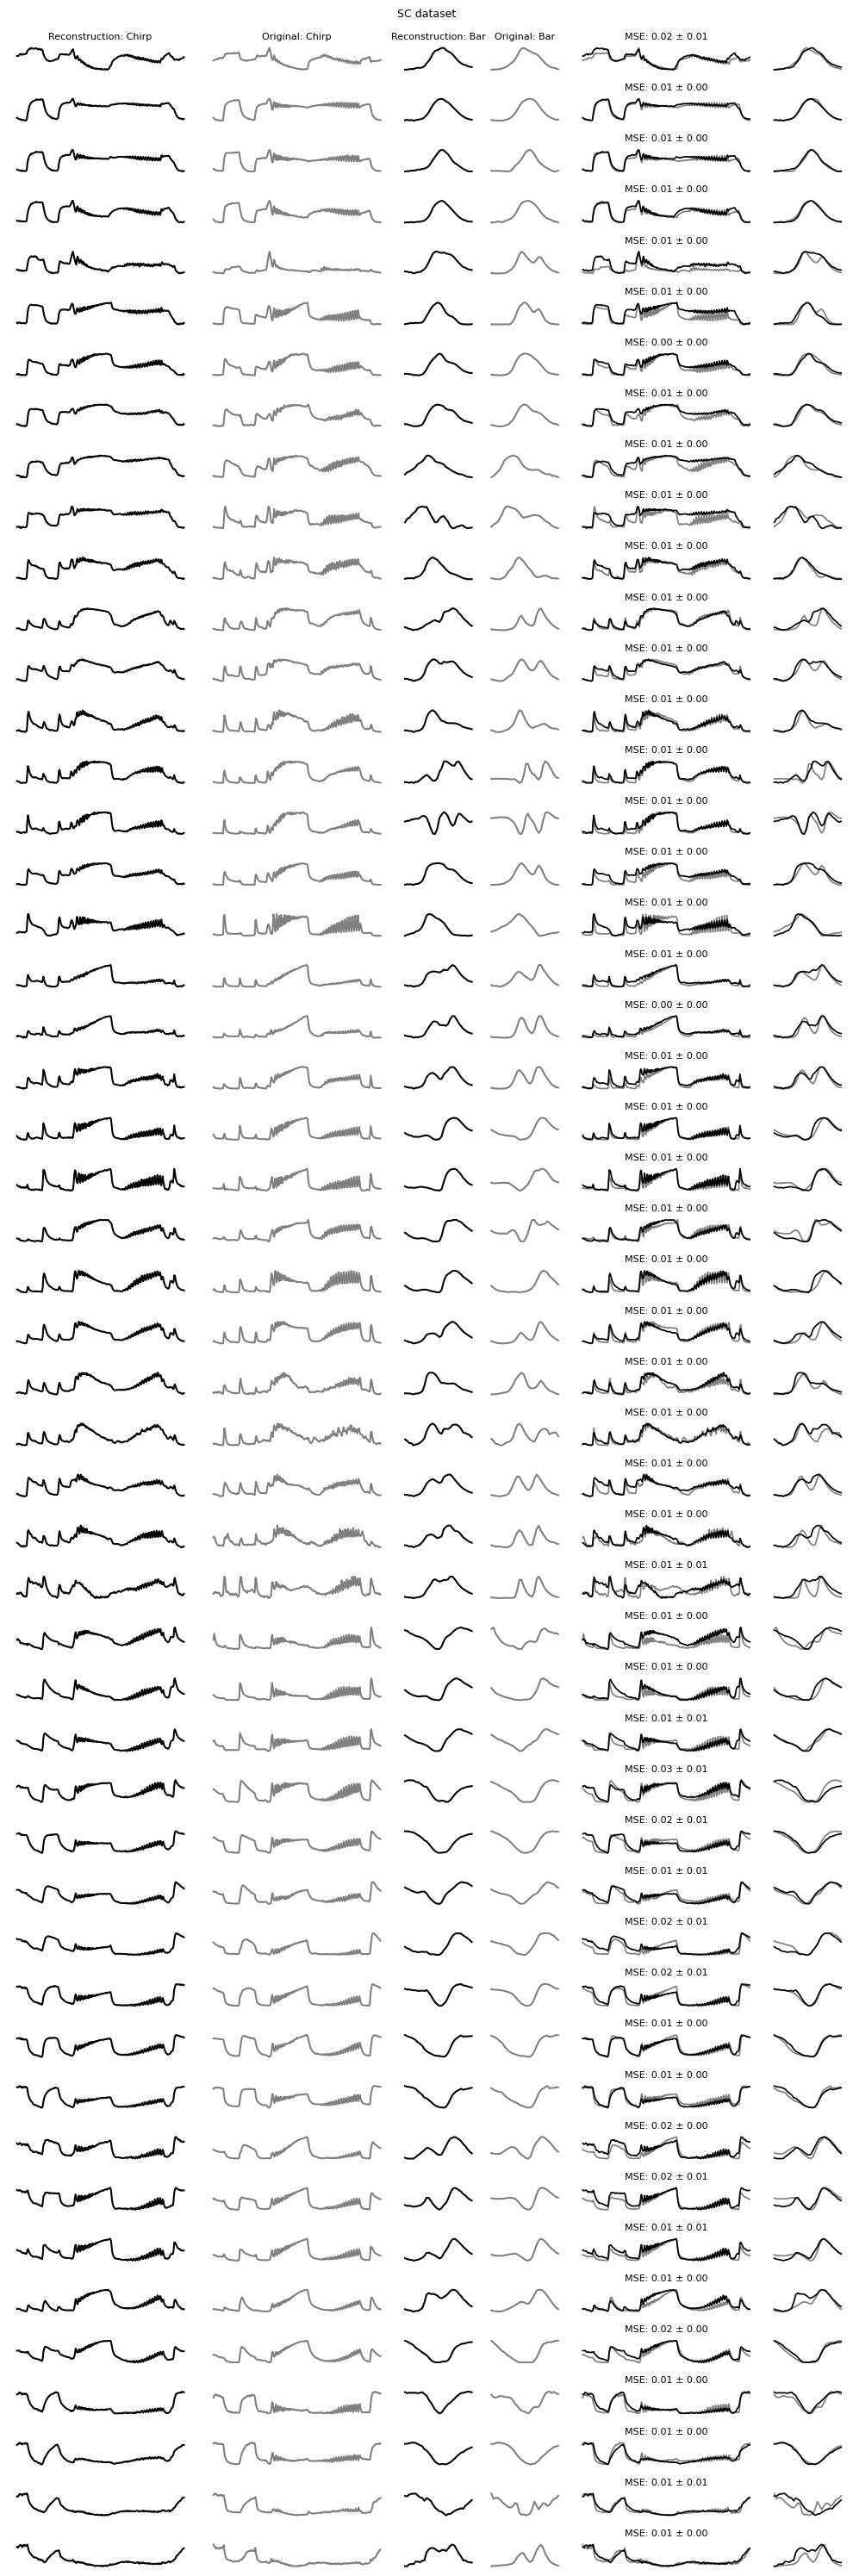

In [21]:
fig, ax = plt.subplots(50, 6, figsize=(10, 30),gridspec_kw={'width_ratios': [2.5, 2.5, 1., 1., 2.5, 1.]})

for i in range(len(np.unique(y_sc))):
    idx = np.where(y_sc == i)[0]

    mean_sc_recon_chirp = X_rec_sc_chirp[idx, :].mean(axis=0)
    mean_sc_orig_chirp = X_orig_sc_chirp[idx, :].mean(axis=0)

    mean_sc_recon_bar = X_rec_sc_bar[idx, :].mean(axis=0)
    mean_sc_orig_bar = X_orig_sc_bar[idx, :].mean(axis=0)
    
    # main axis
    ax[i,0].plot(mean_sc_recon_chirp, color='k', label='Recon')
    ax[i,1].plot(mean_sc_orig_chirp, color='gray', label='Original')
    ax[i,2].plot(mean_sc_recon_bar, color='k', label='Recon')
    ax[i,3].plot(mean_sc_orig_bar, color='gray', label='Original')
    
    lw=1.25
    # twin axis sharing x
    ax[i,4].plot(mean_sc_orig_chirp, color='gray', label='Recon',lw=lw)
    ax2 = ax[i,4].twinx()
    ax2.plot(mean_sc_recon_chirp, color='k', label='Original',lw=lw)

    ax[i,5].plot(mean_sc_orig_bar, color='gray', label='Recon',lw=lw)
    ax3 = ax[i,5].twinx()
    ax3.plot(mean_sc_recon_bar, color='k', label='Original',lw=lw)

    ax[i,0].axis('off')     
    ax[i,1].axis('off')      
    ax[i,2].axis('off') 
    ax[i,3].axis('off')     
    ax[i,4].axis('off')     
    ax[i,5].axis('off')     
    ax2.axis('off')
    ax3.axis('off')
    ax[0,0].set_title('Reconstruction: Chirp',fontsize=8)
    ax[0,1].set_title('Original: Chirp',fontsize=8)
    ax[0,2].set_title('Reconstruction: Bar',fontsize=8)
    ax[0,3].set_title('Original: Bar',fontsize=8)
    ax[i,4].set_title(f"MSE: {mse_sc[y_sc_only == i].mean():.2f} ± {mse_sc[y_sc_only == i].std():.2f}",fontsize=8)
fig.suptitle('SC dataset', y=0.995, fontsize=9)
fig.tight_layout()
plt.show()

## t-SNE of Preprocessed Datasets

In [ ]:
tsne_raw = TSNE(n_components=2, perplexity=50, metric='cosine', random_state=42, learning_rate='auto', n_jobs=15).fit_transform(X_combined)

In [ ]:
fig,ax=plt.subplots(1,3,figsize=(5,2.5))

ax[0].scatter(tsne_raw[domain_labels==0,0], tsne_raw[domain_labels==0,1], s=1, alpha=0.5, label='RGC', color='tab:blue', rasterized=True,edgecolor=None,linewidth=0)
ax[0].scatter(tsne_raw[domain_labels==1,0], tsne_raw[domain_labels==1,1], s=1, alpha=0.1, label='SC', color='tab:red', rasterized=True,edgecolor=None,linewidth=0)
ax[0].set_title('Joint domains',fontsize=10)
ax[0].axis('off')

ax[1].scatter(tsne_raw[domain_labels==1,0], tsne_raw[domain_labels==1,1], s=1, alpha=0.9, label='SC', color='lightgray', rasterized=True,edgecolor=None,linewidth=0)
ax[1].scatter(tsne_raw[domain_labels==0,0], tsne_raw[domain_labels==0,1], s=1, alpha=0.3, label='RGC', color='tab:blue', rasterized=True,edgecolor=None,linewidth=0)
ax[1].set_title('RGC domain',fontsize=10)
ax[1].axis('off')

ax[2].scatter(tsne_raw[domain_labels==0,0], tsne_raw[domain_labels==0,1], s=1, alpha=0.9, label='RGC', color='lightgray', rasterized=True,edgecolor=None,linewidth=0)
ax[2].scatter(tsne_raw[domain_labels==1,0], tsne_raw[domain_labels==1,1], s=1, alpha=0.3, label='SC', color='tab:red', rasterized=True,edgecolor=None,linewidth=0)
ax[2].set_title('SC domain',fontsize=10)
ax[2].axis('off')

fig.suptitle(f"LRaw dataset embedding\nDomain acc: {probe_raw['acc_mean']:.2f} ± {probe_raw['acc_std']:.3f}",fontsize=9)
fig.tight_layout()
sns.despine()
plt.show()

## t-SNE on latent space Z

In [ ]:
tsne_Z = TSNE(n_components=2, perplexity=50, metric='cosine', random_state=42, learning_rate='auto', n_jobs=15).fit_transform(z_all)

In [ ]:
fig,ax=plt.subplots(1,3,figsize=(5,2.5))

ax[0].scatter(tsne_Z[domain_labels==0,0], tsne_Z[domain_labels==0,1], s=1, alpha=0.5, label='RGC', color='tab:blue', rasterized=True,edgecolor=None,linewidth=0)
ax[0].scatter(tsne_Z[domain_labels==1,0], tsne_Z[domain_labels==1,1], s=1, alpha=0.1, label='SC', color='tab:red', rasterized=True,edgecolor=None,linewidth=0)
ax[0].set_title('Joint domains',fontsize=10)
ax[0].axis('off')

ax[1].scatter(tsne_Z[domain_labels==1,0], tsne_Z[domain_labels==1,1], s=1, alpha=0.9, label='SC', color='lightgray', rasterized=True,edgecolor=None,linewidth=0)
ax[1].scatter(tsne_Z[domain_labels==0,0], tsne_Z[domain_labels==0,1], s=1, alpha=0.3, label='RGC', color='tab:blue', rasterized=True,edgecolor=None,linewidth=0)
ax[1].set_title('RGC domain',fontsize=10)
ax[1].axis('off')

ax[2].scatter(tsne_Z[domain_labels==0,0], tsne_Z[domain_labels==0,1], s=1, alpha=0.9, label='RGC', color='lightgray', rasterized=True,edgecolor=None,linewidth=0)
ax[2].scatter(tsne_Z[domain_labels==1,0], tsne_Z[domain_labels==1,1], s=1, alpha=0.3, label='SC', color='tab:red', rasterized=True,edgecolor=None,linewidth=0)
ax[2].set_title('SC domain',fontsize=10)
ax[2].axis('off')

fig.suptitle(f"Latent space (Z) embedding\nDomain acc: {probe['acc_mean']:.2f} ± {probe['acc_std']:.3f}",fontsize=9)
fig.tight_layout();
sns.despine()
plt.show()

## Matching of clusters with groups

In [22]:
# ===========================
# Type centroids & similarity
# ===========================
print("Computing type centroids and cross-dataset similarity...")

z_rgc = z_all[:len(X_rgc_norm_abs)]
z_sc  = z_all[len(X_rgc_norm_abs):]

# RGC centroids
unique_rgc = np.unique(y_rgc)
centroids_rgc = np.vstack([
    z_rgc[y_rgc == k].mean(axis=0) for k in unique_rgc
])

# SC centroids
unique_sc = np.unique(y_sc)
centroids_sc = np.vstack([
    z_sc[y_sc == k].mean(axis=0) for k in unique_sc
])


# Cosine similarity matrix: (n_rgc_types x n_sc_types)
sim_matrix = cosine_similarity(centroids_rgc, centroids_sc)

print("Similarity matrix shape:", sim_matrix.shape)
print("Example: max similarity per RGC type (index, value):")
for i, row in enumerate(sim_matrix):
    j = np.argmax(row)
    print(f"RGC type {unique_rgc[i]} → best SC type {unique_sc[j]} with sim {row[j]:.3f}")

Computing type centroids and cross-dataset similarity...
Similarity matrix shape: (32, 50)
Example: max similarity per RGC type (index, value):
RGC type 0 → best SC type 21 with sim 0.923
RGC type 1 → best SC type 21 with sim 0.921
RGC type 2 → best SC type 22 with sim 0.921
RGC type 3 → best SC type 32 with sim 0.952
RGC type 4 → best SC type 23 with sim 0.924
RGC type 5 → best SC type 25 with sim 0.886
RGC type 6 → best SC type 25 with sim 0.922
RGC type 7 → best SC type 11 with sim 0.935
RGC type 8 → best SC type 24 with sim 0.935
RGC type 9 → best SC type 20 with sim 0.668
RGC type 10 → best SC type 28 with sim 0.947
RGC type 11 → best SC type 20 with sim 0.846
RGC type 12 → best SC type 43 with sim 0.976
RGC type 13 → best SC type 43 with sim 0.860
RGC type 14 → best SC type 13 with sim 0.896
RGC type 15 → best SC type 17 with sim 0.793
RGC type 16 → best SC type 17 with sim 0.949
RGC type 17 → best SC type 26 with sim 0.958
RGC type 18 → best SC type 44 with sim 0.878
RGC type 19

### Plot matching

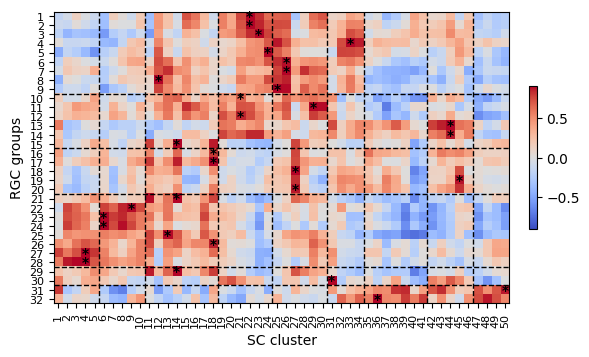

In [24]:
group_ticks_1 = np.arange(1, 33, 1)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
im = ax.imshow(sim_matrix, cmap='coolwarm', vmin=-.9, vmax=.9)

ax.set_xlabel('SC cluster')
ax.set_ylabel('RGC groups')

ax.set_yticks(np.arange(32))
ax.set_yticklabels(group_ticks_1, fontsize=8)

ax.set_xticks(np.arange(len(range(1, 51))))
ax.set_xticklabels(range(1, 51), fontsize=8, rotation=90)

for i in range(sim_matrix.shape[0]):
    j = np.argmax(sim_matrix[i])
    ax.text(j, i, '*', ha='center', va='center', color='black',
            fontsize=10, fontweight='bold')

# horizontal separators
ax.axhline(8.5,  color='k', lw=1, ls='--')
ax.axhline(14.5, color='k', lw=1, ls='--')
ax.axhline(19.5, color='k', lw=1, ls='--')
ax.axhline(27.5, color='k', lw=1, ls='--')
ax.axhline(29.5, color='k', lw=1, ls='--')

# vertical separators
ax.axvline(4.5,  color='k', lw=1, ls='--')
ax.axvline(9.5,  color='k', lw=1, ls='--')
ax.axvline(17.5, color='k', lw=1, ls='--')
ax.axvline(23.5, color='k', lw=1, ls='--')
ax.axvline(29.5, color='k', lw=1, ls='--')
ax.axvline(33.5, color='k', lw=1, ls='--')
ax.axvline(40.5, color='k', lw=1, ls='--')
ax.axvline(45.5, color='k', lw=1, ls='--')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.25)
plt.tight_layout()
plt.show()

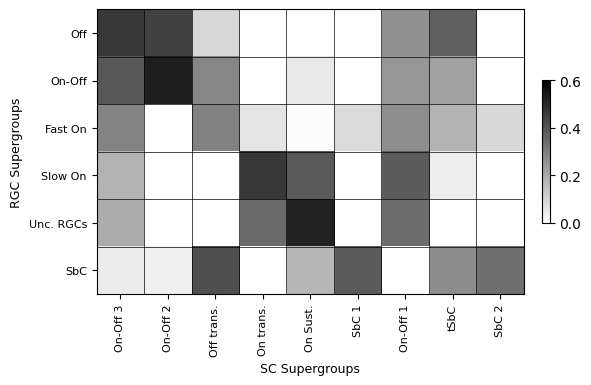

In [27]:
block_count_sim, mean_sim = compute_corr_summary(sim_matrix)

# maximize diagonal
rows, cols = linear_sum_assignment(-mean_sim)

# column permutation: matched cols first, then the rest
perm = list(cols[np.argsort(rows)]) + [
    j for j in range(mean_sim.shape[1]) if j not in cols]

sc_supergroups = ['On Sust.','On trans.','On-Off 1','On-Off 2', 'On-Off 3', 'tSbC', 'SbC 1', 'Off trans.', 'SbC 2']

# permuted matrix
mean_sim_perm = mean_sim[:, perm]
sc_supergroups_perm = [sc_supergroups[j] for j in perm]

rgc_supergroups = ['Off','On-Off','Fast On','Slow On', 'Unc. RGCs', 'SbC']
sc_supergroups = ['On Sust.','On trans.','On-Off 1','On-Off 2', 'On-Off 3', 'tSbC', 'SbC 1', 'Off trans.', 'SbC 2']

fig, ax = plt.subplots(1, 1, figsize=(6,6))

im0 = ax.imshow(mean_sim_perm, cmap='gray_r',vmin=0,vmax=0.6)
ax.set_xlabel("SC Supergroups",fontsize=9)
ax.set_ylabel("RGC Supergroups",fontsize=9)
ax.set_yticks(np.arange(6))
ax.set_yticklabels(rgc_supergroups, fontsize=8)
ax.set_xticks(np.arange(9))
ax.set_xticklabels(sc_supergroups_perm, fontsize=8, rotation=90)

for i in range(6):
    ax.axhline(i+0.5,  color='k', lw=0.5, ls='-')
for i in range(9):
    ax.axvline(i+0.5,  color='k', lw=0.5, ls='-')
    
fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04, shrink=0.25)

plt.tight_layout()
plt.show()

### Matches of RGCs and SCs in tSNE

In [ ]:
fig,ax = plt.subplots(4,10,figsize=(12,6))
r = 0
c = 0

for i, j in enumerate(sim_matrix):
    row = np.argmax(j)
    
    idx_rgc = np.where(y_rgc == i)[0]
    idx_sc = np.where(y_sc == row)[0]

    ax[r,c].scatter(tsne_Z[:,0], tsne_Z[:,1], s=0.5, alpha=0.2, color='lightgray', rasterized=True, edgecolor=None, linewidth=0)
    ax[r,c].scatter(Zz_rgc[idx_rgc,0], Zz_rgc[idx_rgc,1], s=0.5, alpha=0.2, color='tab:blue', rasterized=True, edgecolor=None, linewidth=0)
    ax[r,c].scatter(Zz_sc[idx_sc,0], Zz_sc[idx_sc,1], s=0.5, alpha=0.2, color='tab:red', rasterized=True, edgecolor=None, linewidth=0)
    
    ax[r,c].axis('off')
    ax[r,c].set_title(f"$G_{{{i+1}}}$ -> SC ID: {row+1}",fontsize=8)

    c+=1
    if c==10:
        c=0
        r+=1
ax[3,9].axis('off')
ax[3,8].axis('off')
ax[3,7].axis('off')
ax[3,6].axis('off')
ax[3,4].axis('off')
ax[3,3].axis('off')
ax[3,2].axis('off')
ax[3,5].axis('off')

fig.suptitle(f"RGC & SC matching labels in Z",fontsize=10)
fig.tight_layout()

### Recon. & Raw: RGC -> SC

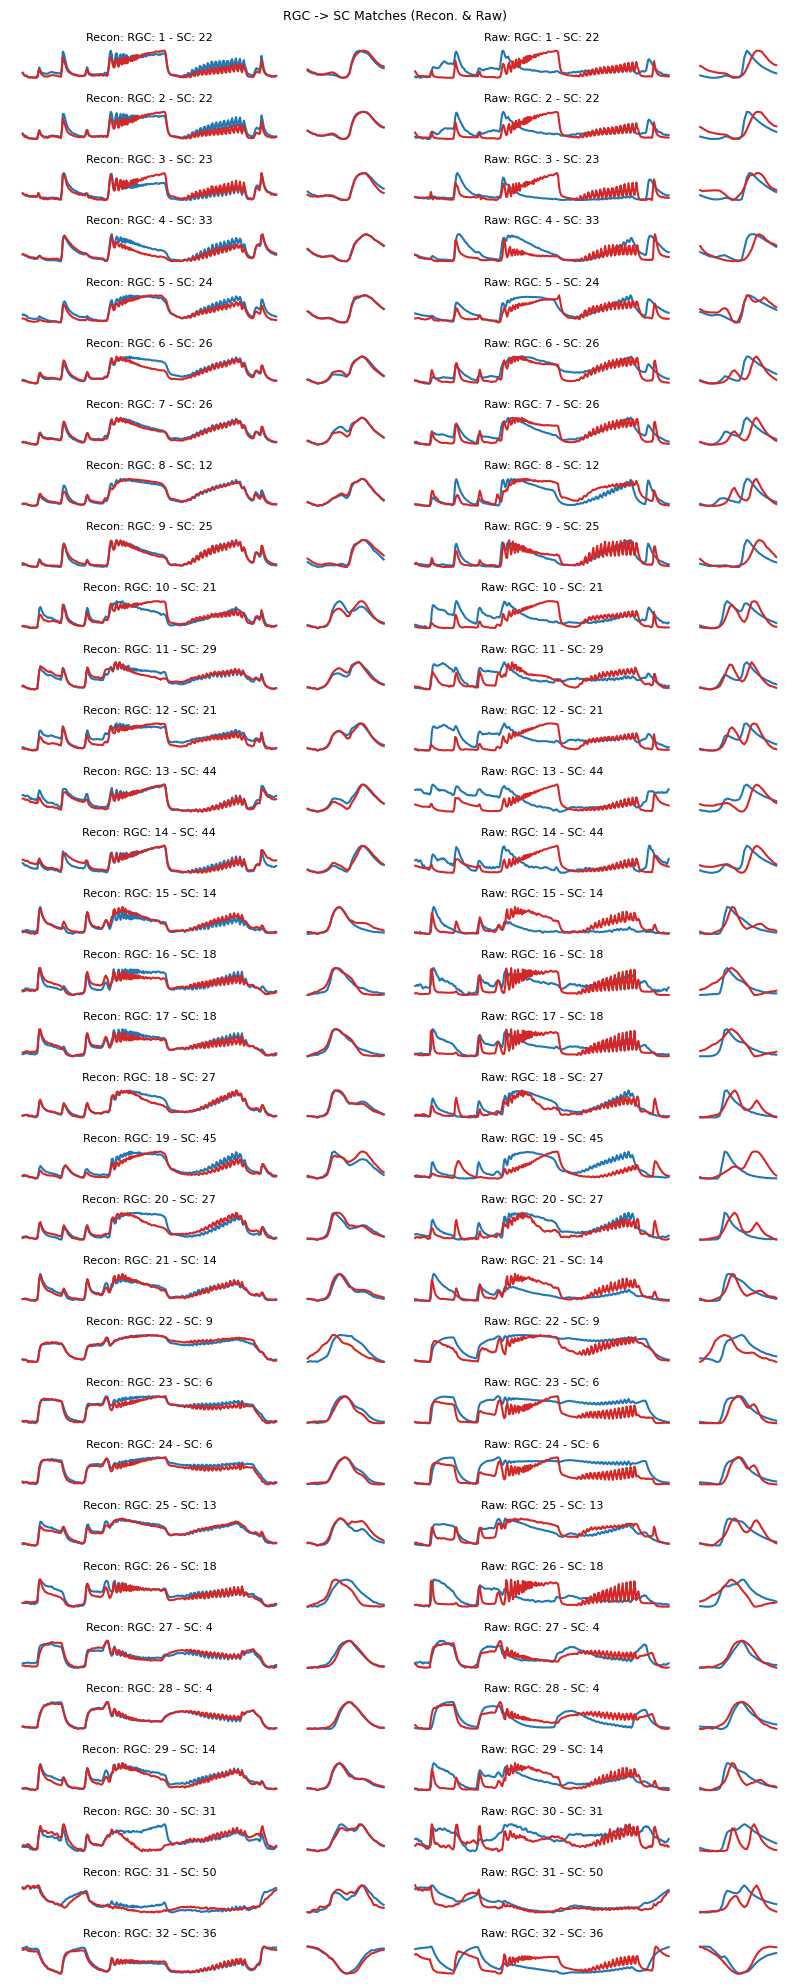

In [30]:
fig, ax = plt.subplots(32, 4, figsize=(8, 20),gridspec_kw={'width_ratios': [2.5, 0.75, 2.5, 0.75]})

for i, row in enumerate(sim_matrix):
    j = np.argmax(row)
    
    idx_rgc = np.where(y_rgc == i)[0]
    idx_sc = np.where(y_sc == j)[0]

    # reconstructions
    mean_rgc_recon_chirp = X_rec_rgc_chirp[idx_rgc, :].mean(axis=0)
    mean_rgc_recon_bar = X_rec_rgc_bar[idx_rgc, :].mean(axis=0)
    mean_sc_recon_chirp = X_rec_sc_chirp[idx_sc, :].mean(axis=0)
    mean_sc_recon_bar = X_rec_sc_bar[idx_sc, :].mean(axis=0)

    # original raw traces
    mean_rgc_orig_chirp = X_orig_rgc_chirp[idx_rgc, :].mean(axis=0)
    mean_rgc_orig_bar = X_orig_rgc_bar[idx_rgc, :].mean(axis=0)
    mean_sc_orig_chirp = X_orig_sc_chirp[idx_sc, :].mean(axis=0)
    mean_sc_orig_bar = X_orig_sc_bar[idx_sc, :].mean(axis=0)
    
       
    # recon
    ax[i,0].plot(mean_rgc_recon_chirp, color='tab:blue', label='Recon')
    ax2 = ax[i,0].twinx()
    ax2.plot(mean_sc_recon_chirp, color='tab:red', label='Original')

    ax[i,1].plot(mean_rgc_recon_bar, color='tab:blue', label='Recon')
    ax3 = ax[i,1].twinx()
    ax3.plot(mean_sc_recon_bar, color='tab:red', label='Original')

    # original
    ax[i,2].plot(mean_rgc_orig_chirp, color='tab:blue', label='Recon')
    ax4 = ax[i,2].twinx()
    ax4.plot(mean_sc_orig_chirp, color='tab:red', label='Original')

    ax[i,3].plot(mean_rgc_orig_bar, color='tab:blue', label='Recon')
    ax5 = ax[i,3].twinx()
    ax5.plot(mean_sc_orig_bar, color='tab:red', label='Original')
  
    ax2.axis('off')
    ax3.axis('off')
    ax4.axis('off')
    ax5.axis('off')
    ax[i,0].axis('off')
    ax[i,1].axis('off')    
    ax[i,2].axis('off')
    ax[i,3].axis('off') 
    
    ax[i,0].set_title(f"Recon: RGC: {unique_rgc[i]+1} - SC: {unique_sc[j]+1}",fontsize=8)
    ax[i,2].set_title(f"Raw: RGC: {unique_rgc[i]+1} - SC: {unique_sc[j]+1}",fontsize=8)
    
fig.suptitle('RGC -> SC Matches (Recon. & Raw)', y=0.99, fontsize=9)
fig.tight_layout()

## Correlation of raw traces vs. reconstructed

In [40]:
corr_chirp_sc = compute_corr(X_orig_sc_chirp, X_rec_sc_chirp)
corr_bar_sc = compute_corr(X_orig_sc_bar, X_rec_sc_bar)
corr_chirp_rgc = compute_corr(X_orig_rgc_chirp, X_rec_rgc_chirp)
corr_bar_rgc = compute_corr(X_orig_rgc_bar, X_rec_rgc_bar)

corr_rgc = compute_corr(X_orig_rgc, X_rec_rgc)
corr_sc = compute_corr(X_orig_sc, X_rec_sc)


mean_corr_rgc = np.zeros(32)
std_corr_rgc = np.zeros(32)

for i in range(len(np.unique(y_rgc))):
    idx = np.where(y_rgc==i)[0]
    mean_corr_rgc[i] = np.mean(corr_rgc[idx])
    std_corr_rgc[i] = np.std(corr_rgc[idx])


mean_corr_sc = np.zeros(50)
std_corr_sc = np.zeros(50)

for i in range(len(np.unique(y_sc))):
    idx = np.where(y_sc==i)[0]
    mean_corr_sc[i] = np.mean(corr_sc[idx])
    std_corr_sc[i] = np.std(corr_sc[idx])

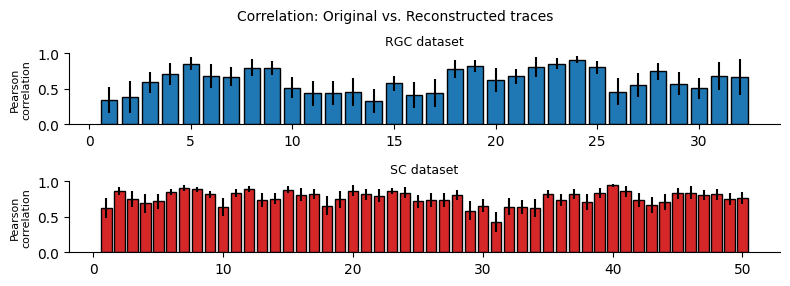

In [42]:
x_tick_rgc = np.arange(1,33)
x_tick_sc = np.arange(1,51)

fig,ax = plt.subplots(2,1,figsize=(8,3))

bars0 = ax[0].bar(np.arange(1,33), mean_corr_rgc, yerr=std_corr_rgc, edgecolor='k', color='tab:blue',alpha=1)
bars1 = ax[1].bar(np.arange(1,51), mean_corr_sc, yerr=std_corr_sc, edgecolor='k', color='tab:red', alpha=1)


ax[0].set_ylim(0,1)
ax[1].set_ylim(0,1)

ax[0].set_title(f"RGC dataset", fontsize=9)
ax[1].set_title(f"SC dataset", fontsize=9)

ax[0].set_ylabel('Pearson\ncorrelation', fontsize=8)
ax[1].set_ylabel('Pearson\ncorrelation', fontsize=8)

fig.suptitle('Correlation: Original vs. Reconstructed traces', y=0.94, fontsize=10)

sns.despine()
fig.tight_layout()